In [1]:
import os
import numpy as np
import pickle
import string
from tqdm import tqdm
import tensorflow as tf
from torch.utils.data import Dataset, DataLoader
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt

In [ ]:
def extract_features(directory):
    model = VGG16()
    model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
    features = {}
    for name in tqdm(os.listdir(directory)):
        filename = os.path.join(directory, name)
        image = load_img(filename, target_size=(224, 224))
        image = img_to_array(image)
        image = np.expand_dims(image, axis=0)
        image = preprocess_input(image)
        feature = model.predict(image, verbose=0)
        image_id = name.split('.')[0]
        features[image_id] = feature
    return features

# Directory where images are stored
images_directory = '/content/drive/MyDrive/DL_Project/flickr30k-images'
features = extract_features(images_directory)

In [ ]:
# Save extracted features to a pickle file
pickle_path = os.path.join('/content/drive/MyDrive/DL_Project', 'features.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump(features, f)

In [2]:
# Load features from the pickle file
with open('/content/drive/MyDrive/DL_Project/features.pkl', 'rb') as f:
    features = pickle.load(f)

In [3]:
import re
from tqdm import tqdm
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
import numpy as np
from sklearn.model_selection import train_test_split

def create_image_caption_mapping(captions_doc):
    mapping = {}
    # process lines
    for line in tqdm(captions_doc.split('\n')):
        # split the line by tab (\t)
        tokens = line.split('\t')
        if len(tokens) < 2:
            continue
        image_id_caption_id, caption = tokens[0], tokens[1]
        # extract image ID (remove the #, digits after it, and the .jpg extension)
        image_id = image_id_caption_id.split('#')[0].split('.')[0]
        # create list if needed
        if image_id not in mapping:
            mapping[image_id] = []
        # store the caption
        mapping[image_id].append(caption)
    return mapping

def clean(mapping):
    cleaned_mapping = {}
    for key, captions in mapping.items():
        cleaned_captions = []
        for caption in captions:
            # preprocessing steps
            # convert to lowercase
            caption = caption.lower()
            # delete digits, special chars, etc., using regex
            caption = re.sub(r'[^a-z\s]', '', caption)
            # delete additional spaces
            caption = re.sub(r'\s+', ' ', caption).strip()
            # add start and end tags to the caption
            cleaned_caption = 'startseq ' + " ".join([word for word in caption.split() if len(word) > 1]) + ' endseq'
            cleaned_captions.append(cleaned_caption)
        cleaned_mapping[key] = cleaned_captions
    return cleaned_mapping

# Specify the relative path to the captions.txt file
file_path = "/content/drive/MyDrive/DL_Project/captions.txt"

# Read captions from the file
with open(file_path, 'r') as file:
    captions_doc = file.read()

# Create the mapping
mapping = create_image_caption_mapping(captions_doc)

# Clean the mapping
cleaned_mapping = clean(mapping)

# Display the keys in the cleaned mapping
print("Available keys in the cleaned mapping:", list(cleaned_mapping.keys())[:10])  # Display first 10 keys for brevity

# Display the cleaned captions for a specific image ID
image_id = '1000092795'
if image_id in cleaned_mapping:
    print(cleaned_mapping[image_id])
else:
    print(f"Image ID {image_id} not found in the cleaned mapping.")


100%|██████████| 158916/158916 [00:00<00:00, 845560.76it/s]


Available keys in the cleaned mapping: ['1000092795', '10002456', '1000268201', '1000344755', '1000366164', '1000523639', '1000919630', '10010052', '1001465944', '1001545525']
['startseq two young guys with shaggy hair look at their hands while hanging out in the yard endseq', 'startseq two young white males are outside near many bushes endseq', 'startseq two men in green shirts are standing in yard endseq', 'startseq man in blue shirt standing in garden endseq', 'startseq two friends enjoy time spent together endseq']


In [4]:

# Create a list of all the training captions
all_train_captions = []
for key, val in cleaned_mapping.items():
    for cap in val:
        all_train_captions.append(cap)

# Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_train_captions)
vocab_size = len(tokenizer.word_index) + 1

# Determine the maximum sequence length
max_length = max(len(c.split()) for c in all_train_captions)

# Display the results
print("Vocabulary Size:", vocab_size)
print("Maximum Sequence Length:", max_length)

Vocabulary Size: 19750
Maximum Sequence Length: 74


In [5]:
# Create a list of image IDs from the cleaned mapping
image_ids = list(cleaned_mapping.keys())

# Split the image IDs into training and testing sets
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

# Display the number of training and testing samples
print("Number of training samples:", len(train))
print("Number of testing samples:", len(test))


Number of training samples: 28604
Number of testing samples: 3179


In [6]:
def data_generator(data_keys, cleaned_mapping, features, tokenizer, max_length, vocab_size, batch_size):
    # loop over images
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = cleaned_mapping[key]
            # process each caption
            for caption in captions:
                # encode the sequence
                seq = tokenizer.texts_to_sequences([caption])[0]
                # split the sequence into X, y pairs
                for i in range(1, len(seq)):
                    # split into input and output pairs
                    in_seq, out_seq = seq[:i], seq[i]
                    # pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    # encode output sequence
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    # store the sequences
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield {"image": X1, "text": X2}, y
                X1, X2, y = list(), list(), list()
                n = 0


In [7]:
from tensorflow.keras.layers import Input, Dropout, Dense, Embedding, LSTM, add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def create_image_captioning_model(vocab_size, max_length):
    inputs1 = Input(shape=(4096,), name="image")
    fe1 = Dropout(0.4)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_length,), name="text")
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.4)(se1)
    se3 = LSTM(256)(se2)

    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer=Adam())

    return model
model = create_image_captioning_model(vocab_size, max_length)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None, 74)]                 0         []                            
                                                                                                  
 image (InputLayer)          [(None, 4096)]               0         []                            
                                                                                                  
 embedding (Embedding)       (None, 74, 256)              5056000   ['text[0][0]']                
                                                                                                  
 dropout (Dropout)           (None, 4096)                 0         ['image[0][0]']               
                                                                                              

In [8]:

epochs = 10
batch_size = 64
steps = len(train) // batch_size

model = create_image_captioning_model(vocab_size, max_length)

for i in range(epochs):
    generator = data_generator(train, cleaned_mapping, features, tokenizer, max_length, vocab_size, batch_size)
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

model.save('/content/drive/MyDrive/DL_Project/output/lstm.h5')


446/446 [==============================] - 189s 424ms/step - loss: 2.9810


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [9]:
def idx_to_word(integer, tokenizer):
    reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}
    return reverse_word_index.get(integer)

def generate_caption(model, image_feature, tokenizer, max_seq_length):
    current_caption = 'startseq'
    for _ in range(max_seq_length):
        sequence = tokenizer.texts_to_sequences([current_caption])[0]
        padded_sequence = pad_sequences([sequence], maxlen=max_seq_length)
        prediction = model.predict([image_feature, padded_sequence], verbose=0)
        predicted_index = np.argmax(prediction)
        predicted_word = idx_to_word(predicted_index, tokenizer)
        if predicted_word is None:
            break
        current_caption += " " + predicted_word
        if predicted_word == 'endseq':
            break
    final_caption = current_caption.split()[1:-1]
    return ' '.join(final_caption)

In [10]:
from nltk.translate.bleu_score import corpus_bleu
actual, predicted = list(), list()
for key in tqdm(test):
    captions = cleaned_mapping[key]
    predicted_caption = generate_caption(model, features[key], tokenizer, max_length)
    actual_captions = [caption.split() for caption in captions]
    predicted_caption = predicted_caption.split()
    actual.append(actual_captions)
    predicted.append(predicted_caption)

print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))


100%|██████████| 3179/3179 [50:15<00:00,  1.05it/s]


BLEU-1: 0.442823
BLEU-2: 0.238008


In [11]:
from tensorflow.keras.layers import GRU

def create_image_captioning_model_gru(vocab_size, max_length):
    # Image feature layers
    inputs1 = Input(shape=(4096,), name="image")
    fe1 = Dropout(0.4)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    # Sequence feature layers
    inputs2 = Input(shape=(max_length,), name="text")
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.4)(se1)
    se3 = GRU(256)(se2)

    # Decoder model
    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model_2 = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model_2.compile(loss='categorical_crossentropy', optimizer=Adam())

    return model_2

model_2 = create_image_captioning_model_gru(vocab_size, max_length)
model_2.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None, 74)]                 0         []                            
                                                                                                  
 image (InputLayer)          [(None, 4096)]               0         []                            
                                                                                                  
 embedding_2 (Embedding)     (None, 74, 256)              5056000   ['text[0][0]']                
                                                                                                  
 dropout_4 (Dropout)         (None, 4096)                 0         ['image[0][0]']               
                                                                                            

In [12]:
epochs = 10
batch_size = 64
steps = len(train) // batch_size

for i in range(epochs):

    generator = data_generator(train, cleaned_mapping, features, tokenizer, max_length, vocab_size, batch_size)
    model_2.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

model_2.save('/content/drive/MyDrive/DL_Project/output/gru.h5')


446/446 [==============================] - 187s 419ms/step - loss: 2.9385


In [13]:
# Validate with test data
actual, predicted = list(), list()

for key in tqdm(test):
    # Get actual captions
    captions = cleaned_mapping[key]
    # Predict the caption for the image
    predicted_caption = generate_caption(model_2, features[key], tokenizer, max_length)
    # Split into words
    actual_captions = [caption.split() for caption in captions]
    predicted_caption = predicted_caption.split()
    # Append to the list
    actual.append(actual_captions)
    predicted.append(predicted_caption)

# Calculate BLEU score
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))


100%|██████████| 3179/3179 [48:24<00:00,  1.09it/s]


BLEU-1: 0.428156
BLEU-2: 0.231673


In [15]:
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LSTM, Bidirectional, add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def create_image_captioning_model_conv_bidirectional(vocab_size, max_length):
    # Image feature layers
    inputs1 = Input(shape=(4096,), name="image")
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(512, activation='relu')(fe1)
    fe3 = Dropout(0.5)(fe2)
    fe4 = Dense(512, activation='relu')(fe3)  # Changed to 512 units

    # Sequence feature layers
    inputs2 = Input(shape=(max_length,), name="text")
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = Bidirectional(LSTM(256, return_sequences=True))(se2)
    se4 = Dropout(0.5)(se3)
    se5 = Bidirectional(LSTM(256))(se4)
    se6 = Dense(512, activation='relu')(se5)  # Added to match shape with fe4

    # Decoder model
    decoder1 = add([fe4, se6])
    decoder2 = Dense(512, activation='relu')(decoder1)
    decoder3 = Dropout(0.5)(decoder2)
    outputs = Dense(vocab_size, activation='softmax')(decoder3)

    model_3 = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model_3.compile(loss='categorical_crossentropy', optimizer=Adam())

    return model_3

model_3 = create_image_captioning_model_conv_bidirectional(vocab_size, max_length)
model_3.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None, 74)]                 0         []                            
                                                                                                  
 embedding_4 (Embedding)     (None, 74, 256)              5056000   ['text[0][0]']                
                                                                                                  
 image (InputLayer)          [(None, 4096)]               0         []                            
                                                                                                  
 dropout_12 (Dropout)        (None, 74, 256)              0         ['embedding_4[0][0]']         
                                                                                            

In [16]:
epochs = 10
batch_size = 64
steps = len(train) // batch_size

for i in range(epochs):
    generator = data_generator(train, cleaned_mapping, features, tokenizer, max_length, vocab_size, batch_size)
    model_3.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

model_3.save('/content/drive/MyDrive/DL_Project/output/conv_bidirectional.h5')


446/446 [==============================] - 258s 579ms/step - loss: 3.4807


In [17]:
# Validate with test data
actual, predicted = list(), list()

for key in tqdm(test):
    captions = cleaned_mapping[key]
    predicted_caption = generate_caption(model_3, features[key], tokenizer, max_length)
    actual_captions = [caption.split() for caption in captions]
    predicted_caption = predicted_caption.split()
    actual.append(actual_captions)
    predicted.append(predicted_caption)

print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

100%|██████████| 3179/3179 [1:11:29<00:00,  1.35s/it]


BLEU-1: 0.449615
BLEU-2: 0.243766


In [26]:
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
def display_and_generate_caption(image_name, model_3, features, tokenizer, max_length, cleaned_mapping):
    # Load the image
    image_id = image_name.split('.')[0]
    img_path = os.path.join("/content/drive/MyDrive/DL_Project/flickr30k-images", image_name)  # Adjust the path as needed
    image = Image.open(img_path)

    # Display actual captions
    captions = cleaned_mapping[image_id]
    print('Actual captions')
    for caption in captions:
        print(caption)

    # Predict the caption
    predicted_caption = generate_caption(model_3, features[image_id], tokenizer, max_length)
    print('Predicted caption')
    print(predicted_caption)

    # Display the image
    plt.imshow(image)
    plt.axis('off')
    plt.show()


Actual captions
startseq two young guys with shaggy hair look at their hands while hanging out in the yard endseq
startseq two young white males are outside near many bushes endseq
startseq two men in green shirts are standing in yard endseq
startseq man in blue shirt standing in garden endseq
startseq two friends enjoy time spent together endseq
Predicted caption
man in blue shirt and jeans is walking down the street


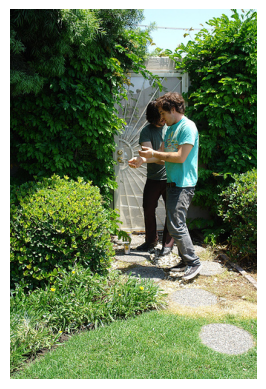

In [27]:
image_name = "1000092795.jpg"
display_and_generate_caption(image_name, model_3, features, tokenizer, max_length, cleaned_mapping)

Actual captions
startseq two children girl and boy are practicing their writing endseq
startseq two children sit on small seesaw in the sand endseq
startseq two children sitting on teeter totter endseq
startseq kids playing on seesaw endseq
startseq two kids sit on seesaw endseq
Predicted caption
two men are playing in the sand


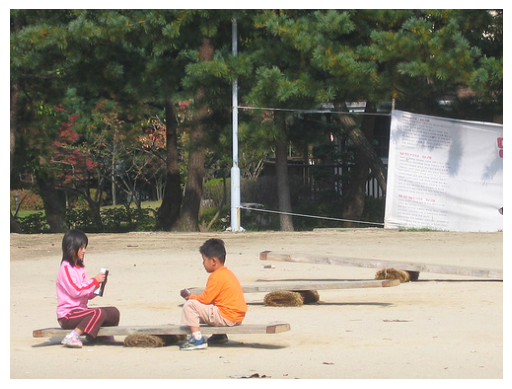

In [28]:
image_name = "1006452823.jpg"
display_and_generate_caption(image_name, model_3, features, tokenizer, max_length, cleaned_mapping)

Actual captions
startseq young individuals in uniforms are gathering under the flags of several different countries endseq
startseq crowd of scouts where there are flags of many nations being held endseq
startseq group of people gather and holding different types of flags endseq
startseq group of people are gathered at some type of outdoor event endseq
startseq reunion of boy scouts from all over the world endseq
Predicted caption
crowd of people are gathered around the crowd


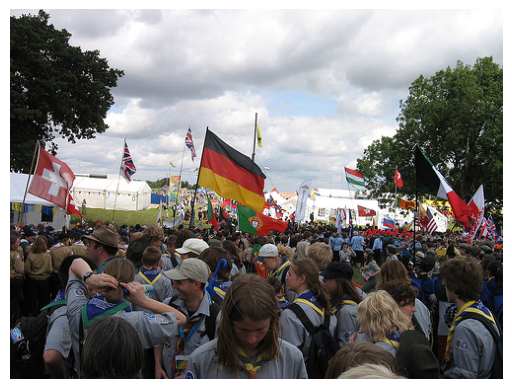

In [29]:
image_name = "1102763701.jpg"
display_and_generate_caption(image_name, model_3, features, tokenizer, max_length, cleaned_mapping)

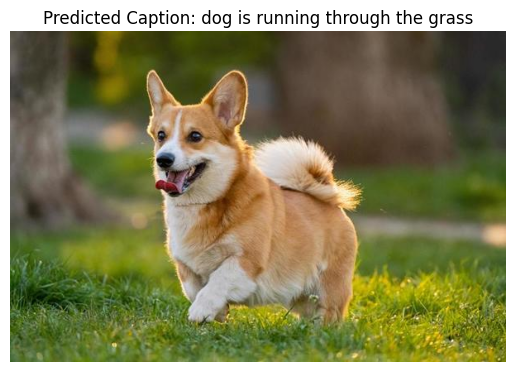

In [39]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

vgg_model = VGG16()
vgg_model = Model(inputs=vgg_model.inputs, outputs=vgg_model.layers[-2].output)

def extract_features(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    feature = vgg_model.predict(image, verbose=0)
    return feature

def idx_to_word(integer, tokenizer):
    reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}
    return reverse_word_index.get(integer)

def generate_caption(model_3, image_feature, tokenizer, max_seq_length):
    current_caption = 'startseq'
    for _ in range(max_seq_length):
        sequence = tokenizer.texts_to_sequences([current_caption])[0]
        padded_sequence = pad_sequences([sequence], maxlen=max_seq_length)
        prediction = model_3.predict([image_feature, padded_sequence], verbose=0)
        predicted_index = np.argmax(prediction)
        predicted_word = idx_to_word(predicted_index, tokenizer)
        if predicted_word is None:
            break
        current_caption += " " + predicted_word
        if predicted_word == 'endseq':
            break
    final_caption = current_caption.split()[1:-1]
    return ' '.join(final_caption)

def generate_caption_for_image(model_3, image_path, tokenizer, max_length):
    features = extract_features(image_path)
    caption = generate_caption(model_3, features, tokenizer, max_length)
    return caption

def display_image_and_caption(image_path, model_3, tokenizer, max_length):
    caption = generate_caption_for_image(model_3, image_path, tokenizer, max_length)
    if not caption:
        caption = "No caption generated."
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title('Predicted Caption: ' + caption)
    plt.show()

image_path = '/content/drive/MyDrive/DL_Project/dog.jpg'
display_image_and_caption(image_path, model_3, tokenizer, max_length)

